In [1]:
import pandas as pd
import numpy as np
import os

# 1. Đường dẫn đến file đã được Preprocess (Cleaned & Null handled)
input_path = '../data/full_df_preprocessed.pkl'

# 2. Đọc file
if os.path.exists(input_path):
    print(f"Đang nạp dữ liệu từ: {input_path}...")
    full_df = pd.read_pickle(input_path)
    print(f"Thành công! Kích thước dữ liệu: {full_df.shape}")
else:
    print(f"LỖI: Không tìm thấy file {input_path}. Hãy chạy file Preprocessing trước.")

# 3. Kiểm tra qua dữ liệu
full_df.head()


Đang nạp dữ liệu từ: ../data/full_df_preprocessed.pkl...
Thành công! Kích thước dữ liệu: (1623718, 53)


,channelGrouping,date,fullVisitorId,visitId,visitNumber,visitStartTime,device_browser,device_operatingSystem,device_isMobile,device_deviceCategory,...,Date_Is_quarter_end,Date_Is_quarter_start,Date_Is_year_end,Date_Is_year_start,visitStartTime_datetime,Date_Hour,transactionRevenue,transactionRevenue_dollar,target_log_revenue,network_type
0,Organic Search,2017-10-16,3162355547410993243,1508198450,1,1508198450,Firefox,Windows,False,desktop,...,0,0,0,0,2017-10-17 00:00:50,0,0.0,0.0,0.0,Other_International
1,Referral,2017-10-16,8934116514970143966,1508176307,6,1508176307,Chrome,Chrome OS,False,desktop,...,0,0,0,0,2017-10-16 17:51:47,17,0.0,0.0,0.0,Other_International
2,Direct,2017-10-16,7992466427990357681,1508201613,1,1508201613,Chrome,Android,True,mobile,...,0,0,0,0,2017-10-17 00:53:33,0,0.0,0.0,0.0,Home_ISP
3,Organic Search,2017-10-16,9075655783635761930,1508169851,1,1508169851,Chrome,Windows,False,desktop,...,0,0,0,0,2017-10-16 16:04:11,16,0.0,0.0,0.0,Other_International
4,Organic Search,2017-10-16,6960673291025684308,1508190552,1,1508190552,Chrome,Windows,False,desktop,...,0,0,0,0,2017-10-16 21:49:12,21,0.0,0.0,0.0,Other_International


In [2]:
full_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1623718 entries, 0 to 1623717
Data columns (total 53 columns):
 #   Column                                    Non-Null Count    Dtype         
---  ------                                    --------------    -----         
 0   channelGrouping                           1623718 non-null  object        
 1   date                                      1623718 non-null  datetime64[ns]
 2   fullVisitorId                             1623718 non-null  object        
 3   visitId                                   1623718 non-null  int64         
 4   visitNumber                               1623718 non-null  int64         
 5   visitStartTime                            1623718 non-null  int64         
 6   device_browser                            1623718 non-null  object        
 7   device_operatingSystem                    1623718 non-null  object        
 8   device_isMobile                           1623718 non-null  bool          
 9   device_device

Train Test Split

In [3]:
import pandas as pd
from datetime import timedelta

def generate_time_folds(df, date_col='date', feature_days=168, target_days=92, slide_days=60):
    min_date = df[date_col].min()
    max_date = df[date_col].max()

    print(f"Dữ liệu gốc: Từ {min_date.date()} đến {max_date.date()}\n")  # sửa lỗi 1

    folds = []
    current_start = min_date
    fold_idx = 1

    while True:
        feature_end  = current_start + timedelta(days=feature_days)
        target_start = feature_end
        target_end   = target_start + timedelta(days=target_days)

        if target_end >= max_date:   # sửa lỗi 2: >= thay vì >
            break

        folds.append({
            'Fold': fold_idx,
            'Feature_Start': current_start,
            'Feature_End':   feature_end,
            'Target_Start':  target_start,
            'Target_End':    target_end
        })

        current_start += timedelta(days=slide_days)
        fold_idx += 1

    if len(folds) < 3:   # guard mới
        raise ValueError(f"Chỉ có {len(folds)} fold, cần ít nhất 3 (train/val/test)")

    return pd.DataFrame(folds)

In [4]:

# 1. TẠO CÁC MỐC THỜI GIAN
# (Lưu ý: Đảm bảo cột 'date' trong full_df của bạn đã có kiểu datetime64)
folds_info_df = generate_time_folds(full_df, date_col='date')
# 2. CHIA TRAIN / VAL / TEST (Dựa trên index của Fold)
total_folds = len(folds_info_df)
def assign_split_type(fold_id, total_folds):
    if fold_id == total_folds:
        return "TEST"
    elif fold_id == total_folds - 1:
        return "VAL"
    else:
        return "TRAIN"
folds_info_df['Split_Type'] = folds_info_df['Fold'].apply(lambda x: assign_split_type(x, total_folds))
# 3. HIỂN THỊ KẾT QUẢ RÕ RÀNG
print(f"=== CHIẾN LƯỢC CHIA TRAIN/VAL/TEST (Tổng số: {total_folds} Folds) ===\n")
for index, row in folds_info_df.iterrows():
    print(f"Fold {row['Fold']:<2} | {row['Split_Type']:<5} | "
          f"Feature: {row['Feature_Start'].date()} ──> {row['Feature_End'].date()} | "
          f"Target: {row['Target_Start'].date()} ──> {row['Target_End'].date()}")

Dữ liệu gốc: Từ 2016-08-01 đến 2018-04-30

=== CHIẾN LƯỢC CHIA TRAIN/VAL/TEST (Tổng số: 7 Folds) ===

Fold 1  | TRAIN | Feature: 2016-08-01 ──> 2017-01-16 | Target: 2017-01-16 ──> 2017-04-18
Fold 2  | TRAIN | Feature: 2016-09-30 ──> 2017-03-17 | Target: 2017-03-17 ──> 2017-06-17
Fold 3  | TRAIN | Feature: 2016-11-29 ──> 2017-05-16 | Target: 2017-05-16 ──> 2017-08-16
Fold 4  | TRAIN | Feature: 2017-01-28 ──> 2017-07-15 | Target: 2017-07-15 ──> 2017-10-15
Fold 5  | TRAIN | Feature: 2017-03-29 ──> 2017-09-13 | Target: 2017-09-13 ──> 2017-12-14
Fold 6  | VAL   | Feature: 2017-05-28 ──> 2017-11-12 | Target: 2017-11-12 ──> 2018-02-12
Fold 7  | TEST  | Feature: 2017-07-27 ──> 2018-01-11 | Target: 2018-01-11 ──> 2018-04-13


In [5]:
train_folds = folds_info_df[folds_info_df['Split_Type'] == 'TRAIN']

# Lấy toàn bộ session nằm trong bất kỳ feature window nào của train folds
# (không dùng target window vì categorical grouping chỉ apply lên X)
mask = pd.Series(False, index=full_df.index)
for _, row in train_folds.iterrows():
    mask |= (
        (full_df['date'] >= row['Feature_Start']) &
        (full_df['date'] <  row['Feature_End'])
    )

df_train_sessions = full_df[mask].copy()
print(f"Train sessions để tìm top-N: {len(df_train_sessions):,} rows")

Train sessions để tìm top-N: 963,393 rows


Tìm top-n config bằng elbow


giữ nguyên
device_deviceCategory    (3 unique)
trafficSource_medium     (5 unique)
geoNetwork_continent     (5 unique)
customDimensions_value   (6 unique)
channelGrouping          (8 unique)
network_type             (4 unique)

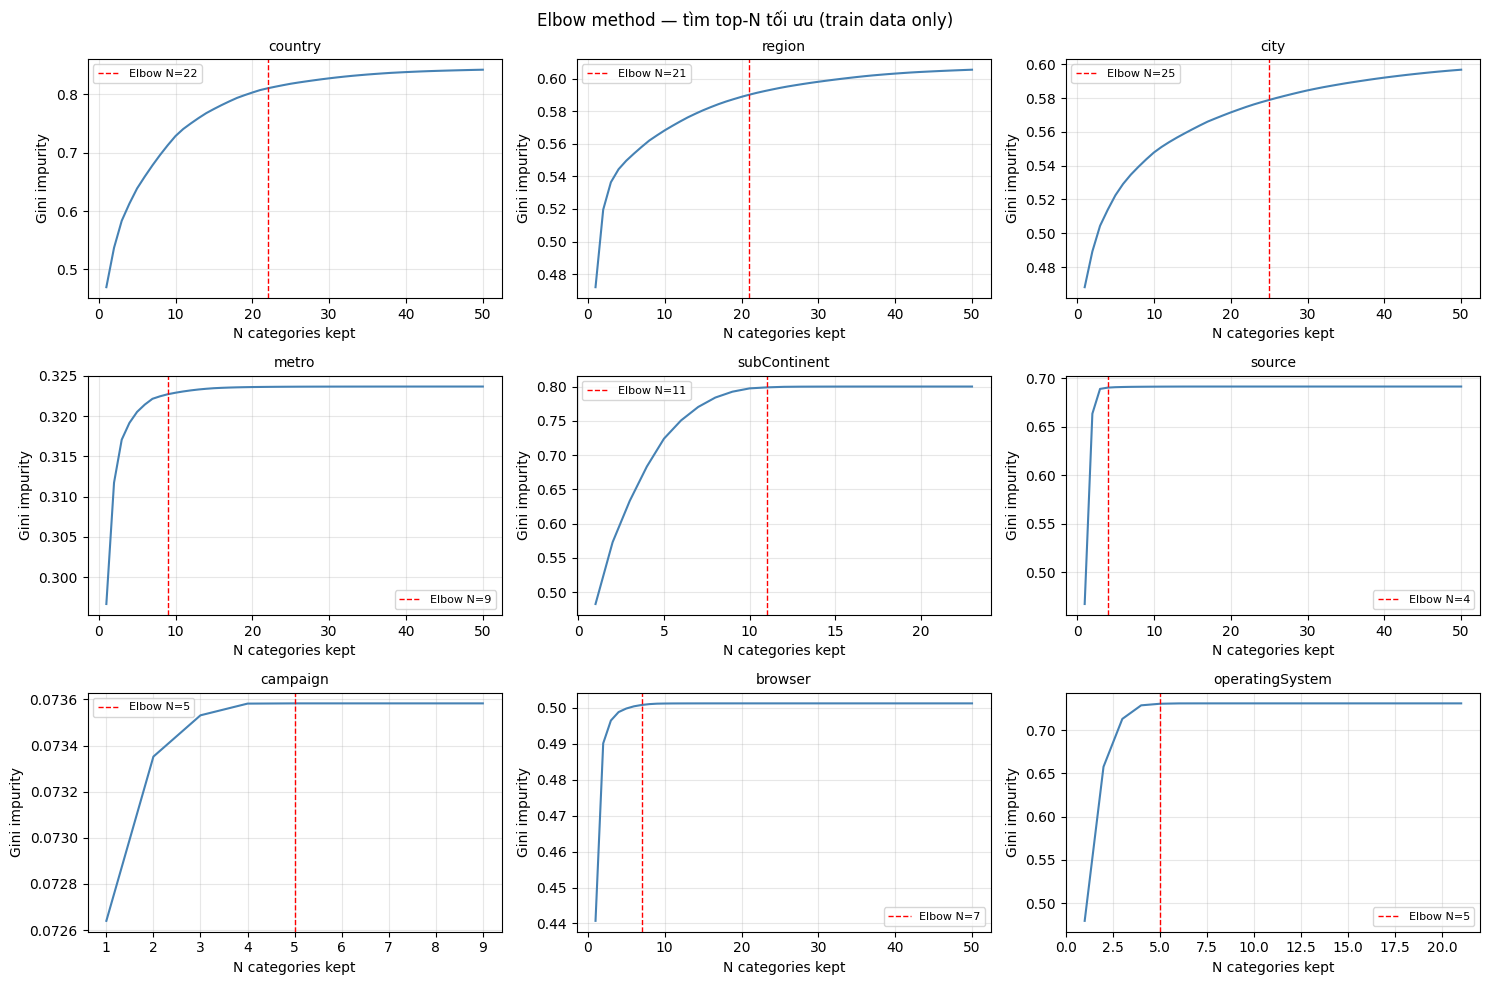


=== TOPN_CONFIGS (từ Elbow) ===
  geoNetwork_country                 : N= 22 | Other=18.9% ✅
  geoNetwork_region                  : N= 21 | Other=13.9% ✅
  geoNetwork_city                    : N= 25 | Other=16.1% ✅
  geoNetwork_metro                   : N=  9 | Other=3.2% ✅
  geoNetwork_subContinent            : N= 11 | Other=4.1% ✅
  trafficSource_source               : N=  4 | Other=3.5% ✅
  trafficSource_campaign             : N=  5 | Other=0.0% ✅
  device_browser                     : N=  7 | Other=2.4% ✅
  device_operatingSystem             : N=  5 | Other=3.4% ✅


In [6]:
import numpy as np
import matplotlib.pyplot as plt

CAT_COLS = [
    'geoNetwork_country', 'geoNetwork_region', 'geoNetwork_city',
    'geoNetwork_metro', 'geoNetwork_subContinent',
    'trafficSource_source', 'trafficSource_campaign',
    'device_browser', 'device_operatingSystem',
]

def find_elbow_n(series, max_n=50):
    """
    Tính Gini impurity theo N, tìm elbow = điểm
    marginal gain < 1% tổng range.
    Trả về n tối ưu và bảng kết quả.
    """
    counts = series.value_counts(normalize=True)
    max_n  = min(max_n, len(counts))

    records = []
    for n in range(1, max_n + 1):
        top_probs   = counts.iloc[:n]
        other_prob  = 1 - top_probs.sum()
        all_probs   = list(top_probs) + ([other_prob] if other_prob > 1e-9 else [])
        gini        = 1 - sum(p**2 for p in all_probs)
        records.append({'n': n, 'gini': gini})

    df_res = pd.DataFrame(records)
    df_res['marginal'] = df_res['gini'].diff().abs().fillna(0)

    gini_range = df_res['gini'].max() - df_res['gini'].min()
    threshold  = gini_range * 0.01   # gain < 1% range = dừng

    # Elbow = N nhỏ nhất mà từ đó marginal gain luôn < threshold
    elbow_n = max_n  # fallback
    for i, row in df_res.iterrows():
        if row['n'] >= 2 and df_res.loc[i:, 'marginal'].max() < threshold:
            elbow_n = int(row['n'])
            break

    return elbow_n, df_res


# Chạy cho tất cả cột và vẽ
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

TOPN_CONFIGS = {}

for idx, col in enumerate(CAT_COLS):
    elbow_n, df_res = find_elbow_n(df_train_sessions[col], max_n=50)
    TOPN_CONFIGS[col] = elbow_n

    ax = axes[idx]
    ax.plot(df_res['n'], df_res['gini'], color='steelblue', linewidth=1.5)
    ax.axvline(x=elbow_n, color='red', linestyle='--', linewidth=1,
               label=f'Elbow N={elbow_n}')
    ax.set_title(col.split('_')[-1], fontsize=10)
    ax.set_xlabel('N categories kept')
    ax.set_ylabel('Gini impurity')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Elbow method — tìm top-N tối ưu (train data only)', fontsize=12)
plt.tight_layout()
plt.show()

print("\n=== TOPN_CONFIGS (từ Elbow) ===")
for col, n in TOPN_CONFIGS.items():
    other_pct = (~df_train_sessions[col].isin(
        df_train_sessions[col].value_counts().nlargest(n).index
    )).mean() * 100
    flag = "⚠ Other > 30%" if other_pct > 30 else "✅"
    print(f"  {col:<35}: N={n:>3} | Other={other_pct:.1f}% {flag}")

FIT CATEGORICAL MAPPING TỪ TRAIN SESSIONS

In [7]:

fitted_cat_mappings = {}

print("=== TẠO CATEGORICAL MAPPING (Chỉ từ Train) ===")
for col, n in TOPN_CONFIGS.items():
    # 1. Tìm Top N categories phổ biến nhất TRÊN TẬP TRAIN
    top_cats = df_train_sessions[col].value_counts(dropna=False).nlargest(n).index
    
    # 2. Lưu vào dictionary dưới dạng tập hợp (set) để mapping siêu tốc
    fitted_cat_mappings[col] = set(top_cats)
    
    # In ra một số categories mẫu để kiểm tra
    sample_cats = list(top_cats)[:3] 
    print(f"[{col:<25}]: Đã lưu {len(top_cats):>2} categories. (Ví dụ: {sample_cats}...)")

print("\nHoàn thành! fitted_cat_mappings đã sẵn sàng để transform cho Val/Test.")


=== TẠO CATEGORICAL MAPPING (Chỉ từ Train) ===
[geoNetwork_country       ]: Đã lưu 22 categories. (Ví dụ: ['United States', 'India', 'United Kingdom']...)
[geoNetwork_region        ]: Đã lưu 21 categories. (Ví dụ: ['unknown', 'California', 'New York']...)
[geoNetwork_city          ]: Đã lưu 25 categories. (Ví dụ: ['unknown', 'New York', 'San Francisco']...)
[geoNetwork_metro         ]: Đã lưu  9 categories. (Ví dụ: ['unknown', 'San Francisco-Oakland-San Jose CA', 'New York NY']...)
[geoNetwork_subContinent  ]: Đã lưu 11 categories. (Ví dụ: ['Northern America', 'Southeast Asia', 'Southern Asia']...)
[trafficSource_source     ]: Đã lưu  4 categories. (Ví dụ: ['direct', 'google', 'youtube']...)
[trafficSource_campaign   ]: Đã lưu  5 categories. (Ví dụ: ['no_campaign', 'Data Share Promo', 'AW - Dynamic Search Ads Whole Site']...)
[device_browser           ]: Đã lưu  7 categories. (Ví dụ: ['Chrome', 'Safari', 'Firefox']...)
[device_operatingSystem   ]: Đã lưu  5 categories. (Ví dụ: ['Window

In [8]:
# FIT CÁC ENCODERS TRÊN TRAIN SESSIONS
# (Chạy 1 lần, trước vòng lặp fold)
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data

# --- A. Fit Target Encoders (Geographic Wealth + Device Quality) ---
# Chỉ dùng df_train_sessions để tránh leakage
global_mean_rev = df_train_sessions['transactionRevenue'].mean()

# Geographic Wealth: city → mean revenue
geo_enc = (df_train_sessions.groupby('geoNetwork_city')['transactionRevenue']
           .mean().to_dict())

# Device Quality: browser + OS → mean revenue  
browser_enc = (df_train_sessions.groupby('device_browser')['transactionRevenue']
               .mean().to_dict())
os_enc = (df_train_sessions.groupby('device_operatingSystem')['transactionRevenue']
          .mean().to_dict())

# --- B. Fit BG/NBD + Gamma-Gamma trên train transactions ---
# Chỉ lấy session có mua hàng
train_transactions = df_train_sessions[
    df_train_sessions['transactionRevenue'] > 0
][['fullVisitorId', 'date', 'transactionRevenue']].copy()

# Tạo summary BTYD (cần ít nhất 2 lần mua để fit)
train_summary = summary_data_from_transaction_data(
    train_transactions,
    customer_id_col='fullVisitorId',
    datetime_col='date',
    monetary_value_col='transactionRevenue',
    observation_period_end=df_train_sessions['date'].max(),
    freq='D'
)

# Fit BG/NBD
bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(
    train_summary['frequency'],
    train_summary['recency'],
    train_summary['T']
)
print(f"BG/NBD fitted. Buyers in train: {len(train_summary):,}")

# Fit Gamma-Gamma (chỉ dùng user có frequency > 0)
gg_data = train_summary[train_summary['frequency'] > 0]
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(gg_data['frequency'], gg_data['monetary_value'])
print(f"Gamma-Gamma fitted. Repeat buyers: {len(gg_data):,}")

BG/NBD fitted. Buyers in train: 10,062
Gamma-Gamma fitted. Repeat buyers: 927


In [9]:
# VÒNG LẶP FOLD (aggregate + apply features)
processed_folds = []

for idx, fold_row in folds_info_df.iterrows():
    fold_id          = fold_row['Fold']
    split_type       = fold_row['Split_Type']
    feature_end_date = fold_row['Feature_End']
    print(f"\nFold {fold_id} ({split_type})...")

    # A. Cắt Feature Window
    mask_feat = (
        (full_df['date'] >= fold_row['Feature_Start']) &
        (full_df['date'] <  fold_row['Feature_End'])
    )
    df_feat = full_df[mask_feat].copy()

    # B. Apply categorical mapping
    for col, keep_set in fitted_cat_mappings.items():
        df_feat[col] = np.where(
            df_feat[col].isin(keep_set), df_feat[col], 'Other'
        )

    # C. Aggregate → user-level
    agg_dict = {
        'visitId':                  'count',
        'visitNumber':               'max',
        'totals_hits':              ['sum', 'mean'],
        'totals_pageviews':         ['sum', 'mean'],
        'totals_timeOnSite':        ['sum', 'mean'],
        'totals_bounces':            'mean',
        'totals_sessionQualityDim': ['mean', 'max'],
        'transactionRevenue':       ['sum', 'mean', 'max'],
        'totals_transactions':       'sum',
        'device_isMobile':           'mean',
        **{col: 'last' for col in fitted_cat_mappings.keys()},
        'channelGrouping':           'last',
        'device_deviceCategory':     'last',
        'trafficSource_medium':      'last',
    }

    named_aggs = {
        'pct_weekend': pd.NamedAgg(
            column='Date_Dayofweek',
            aggfunc=lambda x: (x >= 5).mean()
        ),
        'pct_evening': pd.NamedAgg(
            column='Date_Hour',
            aggfunc=lambda x: x.between(20, 22).mean()
        ),
    }

    X_user = df_feat.groupby('fullVisitorId').agg({**agg_dict})
    X_user.columns = ['_'.join(str(c) for c in col).strip('_')
                      for col in X_user.columns]
    X_user = X_user.reset_index()

    # Tính named aggs riêng rồi merge
    X_named = df_feat.groupby('fullVisitorId').agg(**named_aggs).reset_index()
    X_user = X_user.merge(X_named, on='fullVisitorId', how='left')

    # D. Contextual features
    X_user['geo_wealth_score']      = X_user['geoNetwork_city_last'].map(geo_enc).fillna(global_mean_rev)
    X_user['browser_quality_score'] = X_user['device_browser_last'].map(browser_enc).fillna(global_mean_rev)
    X_user['os_quality_score']      = X_user['device_operatingSystem_last'].map(os_enc).fillna(global_mean_rev)

    X_user = X_user.rename(columns={'totals_hits_mean': 'funnel_depth'})
# Recency, Hibernation & Velocity
    visit_stats = df_feat.groupby('fullVisitorId').agg(
        last_visit_date =('date', 'max'),
        first_visit_date=('date', 'min'),
        visit_count     =('visitId', 'count')
    ).reset_index()

    visit_stats['recency_days']  = (feature_end_date - visit_stats['last_visit_date']).dt.days
    visit_stats['lifetime_days'] = (visit_stats['last_visit_date'] - visit_stats['first_visit_date']).dt.days

    X_user = X_user.merge(
        visit_stats[['fullVisitorId', 'recency_days', 'lifetime_days']],
        on='fullVisitorId', how='left'
    )

    # Hibernation flag
    repeat_users = visit_stats[visit_stats['visit_count'] > 1].copy()
    repeat_users['inter_visit_time'] = repeat_users['lifetime_days'] / (repeat_users['visit_count'] - 1)
    ivt_mean = repeat_users['inter_visit_time'].mean()
    ivt_std  = repeat_users['inter_visit_time'].std()
    hibernate_threshold = ivt_mean + 2 * ivt_std
    X_user['hibernation_flag'] = (X_user['recency_days'] > hibernate_threshold).astype(int)

    # Velocity: Last 30d vs Previous 90d
    date_30d_ago  = feature_end_date - pd.Timedelta(days=30)
    date_120d_ago = feature_end_date - pd.Timedelta(days=120)

    v30 = df_feat[df_feat['date'] >= date_30d_ago].groupby('fullVisitorId').agg(
        pv_last30      =('totals_pageviews', 'mean'),
        hits_last30    =('totals_hits',      'mean'),
        sessions_last30=('visitId',          'count')
    ).reset_index()

    v90 = df_feat[
        (df_feat['date'] >= date_120d_ago) & (df_feat['date'] < date_30d_ago)
    ].groupby('fullVisitorId').agg(
        pv_prev90      =('totals_pageviews', 'mean'),
        hits_prev90    =('totals_hits',      'mean'),
        sessions_prev90=('visitId',          'count')
    ).reset_index()

    vel = pd.merge(v90, v30, on='fullVisitorId', how='outer').fillna(0)
    
    vel = vel[vel['fullVisitorId'].isin(X_user['fullVisitorId'])]

    vel['vel_pageviews'] = (vel['pv_last30']       + 1) / (vel['pv_prev90']       + 1)
    vel['vel_hits']      = (vel['hits_last30']     + 1) / (vel['hits_prev90']     + 1)
    vel['vel_sessions']  = (vel['sessions_last30'] + 1) / (vel['sessions_prev90'] + 1)

    X_user = X_user.merge(
        vel[['fullVisitorId', 'vel_pageviews', 'vel_hits', 'vel_sessions']],
        on='fullVisitorId', how='left'
    )
    X_user[['vel_pageviews', 'vel_hits', 'vel_sessions']] = (
        X_user[['vel_pageviews', 'vel_hits', 'vel_sessions']].fillna(1.0)
    )

    # E. CLV/BTYD features
    fold_transactions = df_feat[df_feat['transactionRevenue'] > 0][
        ['fullVisitorId', 'date', 'transactionRevenue']
    ].copy()

    if len(fold_transactions) > 10:
        fold_summary = summary_data_from_transaction_data(
            fold_transactions,
            customer_id_col='fullVisitorId',
            datetime_col='date',
            monetary_value_col='transactionRevenue',
            observation_period_end=feature_end_date,
            freq='D'
        )

        fold_summary['p_alive'] = bgf.conditional_probability_alive(
            fold_summary['frequency'],
            fold_summary['recency'],
            fold_summary['T']
        )
        fold_summary['expected_purchases_62d'] = bgf.conditional_expected_number_of_purchases_up_to_time(
            62,
            fold_summary['frequency'],
            fold_summary['recency'],
            fold_summary['T']
        )

        fold_summary = fold_summary.reset_index()

        repeat = fold_summary[fold_summary['frequency'] > 0][
            ['fullVisitorId', 'frequency', 'monetary_value']
        ].copy()

        if len(repeat) > 0:
            repeat['expected_monetary'] = ggf.conditional_expected_average_profit(
                repeat['frequency'],
                repeat['monetary_value']
            )
            fold_summary = fold_summary.merge(
                repeat[['fullVisitorId', 'expected_monetary']],
                on='fullVisitorId', how='left'
            )
        else:
            fold_summary['expected_monetary'] = 0.0

        fold_summary['expected_monetary'] = fold_summary['expected_monetary'].fillna(0)

        X_user = X_user.merge(
            fold_summary[['fullVisitorId', 'p_alive',
                          'expected_purchases_62d', 'expected_monetary']],
            on='fullVisitorId', how='left'
        )
        btyd_count = fold_summary['p_alive'].gt(0).sum()

    else:
        X_user['p_alive']                = 0.0
        X_user['expected_purchases_62d'] = 0.0
        X_user['expected_monetary']      = 0.0
        btyd_count = 0

    X_user[['p_alive', 'expected_purchases_62d', 'expected_monetary']] = (
        X_user[['p_alive', 'expected_purchases_62d', 'expected_monetary']].fillna(0)
    )

    # F. Target y
    mask_target = (
        (full_df['date'] >= fold_row['Target_Start']) &
        (full_df['date'] <  fold_row['Target_End'])
    )
    y_user = (
        full_df[mask_target]
        .groupby('fullVisitorId')['transactionRevenue']
        .sum().reset_index()
        .rename(columns={'transactionRevenue': 'target_revenue'})
    )
    y_user['target_log_revenue'] = np.log1p(y_user['target_revenue'])

    # G. LEFT JOIN X + y
    fold_data = pd.merge(X_user, y_user, on='fullVisitorId', how='left')
    fold_data['target_revenue']     = fold_data['target_revenue'].fillna(0.0)
    fold_data['target_log_revenue'] = fold_data['target_log_revenue'].fillna(0.0)
    fold_data['Fold']       = fold_id
    fold_data['Split_Type'] = split_type

    processed_folds.append(fold_data)
    
    # In báo cáo
    buyers = (fold_data['target_revenue'] > 0).sum()
    hibernate_count = fold_data['hibernation_flag'].sum()
    print(f"  Users: {len(fold_data):,} | Buyers: {buyers} | BTYD users: {btyd_count} | Hibernating: {hibernate_count:,}")

# Kiểm tra tên cột sau khi chạy xong
print("\n=== Tên cột fold đầu tiên ===")
print(processed_folds[0].columns.tolist())



Fold 1 (TRAIN)...
  Users: 362,805 | Buyers: 249 | BTYD users: 4321 | Hibernating: 304,859

Fold 2 (TRAIN)...
  Users: 355,851 | Buyers: 332 | BTYD users: 4054 | Hibernating: 294,632

Fold 3 (TRAIN)...
  Users: 288,161 | Buyers: 298 | BTYD users: 4261 | Hibernating: 227,208

Fold 4 (TRAIN)...
  Users: 278,131 | Buyers: 357 | BTYD users: 4006 | Hibernating: 217,481

Fold 5 (TRAIN)...
  Users: 292,191 | Buyers: 229 | BTYD users: 4444 | Hibernating: 214,244

Fold 6 (VAL)...
  Users: 337,206 | Buyers: 251 | BTYD users: 3902 | Hibernating: 255,632

Fold 7 (TEST)...
  Users: 373,699 | Buyers: 266 | BTYD users: 3581 | Hibernating: 293,501

=== Tên cột fold đầu tiên ===
['fullVisitorId', 'visitId_count', 'visitNumber_max', 'totals_hits_sum', 'funnel_depth', 'totals_pageviews_sum', 'totals_pageviews_mean', 'totals_timeOnSite_sum', 'totals_timeOnSite_mean', 'totals_bounces_mean', 'totals_sessionQualityDim_mean', 'totals_sessionQualityDim_max', 'transactionRevenue_sum', 'transactionRevenue_mean'

In [10]:
processed_folds[0].info()

<class 'pandas.DataFrame'>
RangeIndex: 362805 entries, 0 to 362804
Data columns (total 47 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   fullVisitorId                  362805 non-null  str    
 1   visitId_count                  362805 non-null  int64  
 2   visitNumber_max                362805 non-null  int64  
 3   totals_hits_sum                362805 non-null  int64  
 4   funnel_depth                   362805 non-null  float64
 5   totals_pageviews_sum           362805 non-null  int64  
 6   totals_pageviews_mean          362805 non-null  float64
 7   totals_timeOnSite_sum          362805 non-null  int64  
 8   totals_timeOnSite_mean         362805 non-null  float64
 9   totals_bounces_mean            362805 non-null  float64
 10  totals_sessionQualityDim_mean  362805 non-null  float64
 11  totals_sessionQualityDim_max   362805 non-null  int64  
 12  transactionRevenue_sum         362805 non

In [12]:
# GOM + SCALE + SAVE

# from sklearn.preprocessing import PowerTransformer

all_folds = pd.concat(processed_folds, ignore_index=True)
train_df  = all_folds[all_folds['Split_Type'] == 'TRAIN'].copy()
val_df    = all_folds[all_folds['Split_Type'] == 'VAL'].copy()
test_df   = all_folds[all_folds['Split_Type'] == 'TEST'].copy()

# # Yeo-Johnson cho cột có thể âm hoặc lệch mạnh
# yj_cols = ['p_alive', 'expected_purchases_62d', 'expected_monetary',
#            'geo_wealth_score', 'browser_quality_score', 'os_quality_score']
# yj_cols = [c for c in yj_cols if c in train_df.columns]

# pt = PowerTransformer(method='yeo-johnson')
# train_df[yj_cols] = pt.fit_transform(train_df[yj_cols].fillna(0))
# val_df[yj_cols]   = pt.transform(val_df[yj_cols].fillna(0))
# test_df[yj_cols]  = pt.transform(test_df[yj_cols].fillna(0))

print(f"Train: {train_df.shape}")
print(f"Val  : {val_df.shape}")
print(f"Test : {test_df.shape}")


Train: (1577139, 47)
Val  : (337206, 47)
Test : (373699, 47)


In [ ]:
# GOM + TRANSFORM + SAVE
import pandas as pd
import numpy as np
from sklearn.preprocessing import PowerTransformer, LabelEncoder
from sklearn.model_selection import KFold

# 1. Gom dữ liệu
# all_folds = pd.concat(processed_folds, ignore_index=True)

# --- ĐỊNH NGHĨA LẠI CÁC NHÓM CỘT CHÍNH XÁC ---
log_cols = [
    'transactionRevenue_sum', 'transactionRevenue_mean', 'transactionRevenue_max', 
    'totals_transactions_sum', 'expected_monetary', 'target_revenue'
]

yj_cols = [
    'visitId_count', 'visitNumber_max', 'totals_hits_sum', 'funnel_depth',
    'totals_pageviews_sum', 'totals_pageviews_mean', 'totals_timeOnSite_sum',
    'totals_timeOnSite_mean', 'totals_bounces_mean', 'totals_sessionQualityDim_mean',
    'totals_sessionQualityDim_max', 'recency_days', 'lifetime_days',
    'vel_pageviews', 'vel_hits', 'vel_sessions', 'p_alive', 'expected_purchases_62d',
    'geo_wealth_score', 'browser_quality_score', 'os_quality_score'
]

te_cols = [
    'geoNetwork_country_last', 'geoNetwork_region_last', 'geoNetwork_city_last', 
    'geoNetwork_metro_last', 'geoNetwork_subContinent_last',
    'trafficSource_source_last', 'trafficSource_campaign_last',
    'device_browser_last', 'device_operatingSystem_last'
]

le_cols = [
    'channelGrouping_last', 'device_deviceCategory_last', 'trafficSource_medium_last'
]

# Chuyển đổi kiểu dữ liệu để tránh lỗi LossySetitemError
for col in yj_cols + log_cols:
    if col in all_folds.columns:
        all_folds[col] = all_folds[col].astype('float64')

# 2. Log Transformation
print("Đang áp dụng Log Transformation...")
for col in log_cols:
    if col in all_folds.columns:
        all_folds[col] = np.log1p(all_folds[col])

# Xác định index
train_idx = all_folds[all_folds['Split_Type'] == 'TRAIN'].index
val_idx   = all_folds[all_folds['Split_Type'] == 'VAL'].index
test_idx  = all_folds[all_folds['Split_Type'] == 'TEST'].index

# 3. Yeo-Johnson
print("Đang áp dụng Yeo-Johnson Transformation...")
pt = PowerTransformer(method='yeo-johnson')
all_folds.loc[train_idx, yj_cols] = pt.fit_transform(all_folds.loc[train_idx, yj_cols].fillna(0))
all_folds.loc[val_idx, yj_cols]   = pt.transform(all_folds.loc[val_idx, yj_cols].fillna(0))
all_folds.loc[test_idx, yj_cols]  = pt.transform(all_folds.loc[test_idx, yj_cols].fillna(0))

# 4. Target Encoding (K-Fold cho Train, Map cho Val/Test)
def apply_kfold_target_encoding(df, train_idx, val_idx, test_idx, cols, target_col='target_log_revenue'):
    for col in cols:
        print(f"  Encoding {col}...")
        kf = KFold(n_splits=5, shuffle=True, random_state=42)
        df.loc[train_idx, f'{col}_te'] = 0.0
        
        actual_train_indices = train_idx.values
        for t_idx_rel, v_idx_rel in kf.split(actual_train_indices):
            t_idx = actual_train_indices[t_idx_rel]
            v_idx = actual_train_indices[v_idx_rel]
            target_mean = df.loc[t_idx].groupby(col)[target_col].mean()
            df.loc[v_idx, f'{col}_te'] = df.loc[v_idx, col].map(target_mean)
        
        global_train_mean = df.loc[train_idx, target_col].mean()
        full_train_mapping = df.loc[train_idx].groupby(col)[target_col].mean()
        
        df.loc[val_idx, f'{col}_te'] = df.loc[val_idx, col].map(full_train_mapping).fillna(global_train_mean)
        df.loc[test_idx, f'{col}_te'] = df.loc[test_idx, col].map(full_train_mapping).fillna(global_train_mean)
        df.loc[train_idx, f'{col}_te'] = df.loc[train_idx, f'{col}_te'].fillna(global_train_mean)

print("Đang áp dụng K-Fold Target Encoding...")
apply_kfold_target_encoding(all_folds, train_idx, val_idx, test_idx, te_cols)

# 5. Label Encoding
print("Đang áp dụng Label Encoding...")
le = LabelEncoder()
for col in le_cols:
    all_folds[col] = le.fit_transform(all_folds[col].astype(str))

# 6. Tách lại tập dữ liệu
all_folds_final = all_folds.drop(columns=te_cols)
train_df = all_folds_final.loc[train_idx].copy()
val_df   = all_folds_final.loc[val_idx].copy()
test_df  = all_folds_final.loc[test_idx].copy()

del all_folds, all_folds_final # Giải phóng RAM
print(f"\n=== HOÀN TẤT BIẾN ĐỔI ===")
print(f"Train size: {train_df.shape} | Val size: {val_df.shape} | Test size: {test_df.shape}")


Đang áp dụng Log Transformation...
Đang áp dụng Yeo-Johnson Transformation...
Đang áp dụng K-Fold Target Encoding...
  Encoding geoNetwork_country_last...
  Encoding geoNetwork_region_last...
  Encoding geoNetwork_city_last...
  Encoding geoNetwork_metro_last...
  Encoding geoNetwork_subContinent_last...
  Encoding trafficSource_source_last...
  Encoding trafficSource_campaign_last...
  Encoding device_browser_last...
  Encoding device_operatingSystem_last...
Đang áp dụng Label Encoding...

=== HOÀN TẤT BIẾN ĐỔI ===
Train size: (1577139, 47) | Val size: (337206, 47) | Test size: (373699, 47)


In [15]:
# FEATURE SELECTION
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from sklearn.feature_selection import chi2, VarianceThreshold
from xgboost import XGBRegressor

# 1. Chuẩn bị dữ liệu cho Feature Selection (Chỉ dùng tập TRAIN)
# Tạo biến mục tiêu nhị phân để làm test thống kê (Mua vs Không mua)
y_train_revenue = train_df['target_log_revenue']
y_train_binary = (train_df['target_revenue'] > 0).astype(int)

# Loại bỏ các cột không phải feature
X_train = train_df.drop(columns=['fullVisitorId', 'target_revenue', 'target_log_revenue', 'Fold', 'Split_Type'])
features = X_train.columns.tolist()

print(f"Số lượng đặc trưng ban đầu: {len(features)}")

# --- BƯỚC 1: VARIANCE THRESHOLD (Ngưỡng phương sai) ---
# Loại bỏ các biến mà 99.9% giá trị là giống nhau
selector = VarianceThreshold(threshold=(.999 * (1 - .999)))
selector.fit(X_train)
low_variance_cols = [f for f, s in zip(features, selector.get_support()) if not s]

print(f"1. Loại bỏ {len(low_variance_cols)} biến có phương sai thấp (99.9% hằng số).")
X_train_filtered = X_train.drop(columns=low_variance_cols)

# --- BƯỚC 2: STATISTICAL FILTERS (Bộ lọc thống kê) ---
# Tách biến liên tục và biến phân loại (đã label/target encode)
# Giả định các biến YJ và Log là liên tục, các biến TE/LE là phân loại
numerical_cols = [c for c in X_train_filtered.columns if c in yj_cols + log_cols]
categorical_cols = [c for c in X_train_filtered.columns if c.endswith('_te') or c in le_cols]

# 2.1 T-Test cho biến liên tục
dropped_stats = []
for col in numerical_cols:
    group1 = X_train_filtered.loc[y_train_binary == 1, col]
    group0 = X_train_filtered.loc[y_train_binary == 0, col]
    
    # Thực hiện T-Test độc lập
    stat, p_val = ttest_ind(group1, group0, equal_var=False)
    if p_val > 0.05: # Không có sự khác biệt ý nghĩa giữa 2 nhóm
        dropped_stats.append(col)

# 2.2 Chi-Square cho biến phân loại
# Lưu ý: Chi2 yêu cầu giá trị không âm. Với Target Encoding, ta dùng p-value từ ANOVA hoặc F-test
# Ở đây ta sẽ dùng F-test (f_classif) thay cho Chi2 để linh hoạt hơn với số thực
from sklearn.feature_selection import f_classif
f_stats, p_vals = f_classif(X_train_filtered[categorical_cols].fillna(0), y_train_binary)
for col, p in zip(categorical_cols, p_vals):
    if p > 0.05:
        dropped_stats.append(col)

print(f"2. Loại bỏ {len(dropped_stats)} biến không có ý nghĩa thống kê (p-value > 0.05).")
X_train_filtered = X_train_filtered.drop(columns=dropped_stats)

# --- BƯỚC 3: MODEL-BASED IMPORTANCE (XGBoost) ---
print("3. Đang chạy XGBoost để tính Feature Importance...")
model_fs = XGBRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)
model_fs.fit(X_train_filtered, y_train_revenue)

# Lấy điểm quan trọng và loại bỏ 25% biến thấp nhất
importance_df = pd.DataFrame({
    'feature': X_train_filtered.columns,
    'importance': model_fs.feature_importances_
}).sort_values(by='importance', ascending=False)

# Ngưỡng 75% (loại bỏ 25% thấp nhất)
keep_count = int(len(importance_df) * 0.75)
keep_features = importance_df.head(keep_count)['feature'].tolist()
dropped_importance = importance_df.tail(len(importance_df) - keep_count)['feature'].tolist()

print(f"3. Loại bỏ {len(dropped_importance)} biến có Importance thấp nhất (25% bottom).")

# --- KẾT QUẢ CUỐI CÙNG ---
final_features = keep_features
print(f"\nSố lượng đặc trưng còn lại: {len(final_features)}")

# Cập nhật lại các tập dữ liệu
train_df_final = train_df[['fullVisitorId', 'target_revenue', 'target_log_revenue', 'Fold', 'Split_Type'] + final_features]
val_df_final   = val_df[['fullVisitorId', 'target_revenue', 'target_log_revenue', 'Fold', 'Split_Type'] + final_features]
test_df_final  = test_df[['fullVisitorId', 'target_revenue', 'target_log_revenue', 'Fold', 'Split_Type'] + final_features]

# Hiển thị Top 10 đặc trưng quan trọng nhất
print("\nTOP 10 ĐẶC TRƯNG QUAN TRỌNG NHẤT:")
print(importance_df.head(10))


Số lượng đặc trưng ban đầu: 42
1. Loại bỏ 9 biến có phương sai thấp (99.9% hằng số).
2. Loại bỏ 0 biến không có ý nghĩa thống kê (p-value > 0.05).
3. Đang chạy XGBoost để tính Feature Importance...
3. Loại bỏ 9 biến có Importance thấp nhất (25% bottom).

Số lượng đặc trưng còn lại: 24

TOP 10 ĐẶC TRƯNG QUAN TRỌNG NHẤT:
                   feature  importance
31  expected_purchases_62d    0.064115
11  transactionRevenue_sum    0.048436
26        hibernation_flag    0.048303
27           vel_pageviews    0.044113
23        os_quality_score    0.042633
24            recency_days    0.039931
5    totals_pageviews_mean    0.038585
19             pct_weekend    0.037740
2          totals_hits_sum    0.035509
20             pct_evening    0.035047


In [ ]:
# FEATURE SELECTION
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from sklearn.feature_selection import f_classif, VarianceThreshold
from xgboost import XGBRegressor

# 1. Chuẩn bị dữ liệu
y_train_revenue = train_df['target_log_revenue']
y_train_binary = (train_df['target_revenue'] > 0).astype(int)
X_train = train_df.drop(columns=['fullVisitorId', 'target_revenue', 'target_log_revenue', 'Fold', 'Split_Type'])
features = X_train.columns.tolist()

print(f"Số lượng đặc trưng ban đầu: {len(features)}")

# --- BƯỚC 1: VARIANCE THRESHOLD ---
selector = VarianceThreshold(threshold=(.999 * (1 - .999)))
X_train_v = X_train.loc[:, selector.fit(X_train).get_support()]
print(f"1. Sau Variance Threshold: Còn {X_train_v.shape[1]} biến (Loại {len(features) - X_train_v.shape[1]} biến)")

# --- BƯỚC 2: CORRELATION FILTER (Mới - Loại bỏ biến trùng lặp) ---
# Nếu 2 biến tương quan > 0.9, chỉ giữ lại 1 biến
corr_matrix = X_train_v.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [column for column in upper.columns if any(upper[column] > 0.90)]
X_train_c = X_train_v.drop(columns=to_drop_corr)
print(f"2. Sau Correlation Filter (>0.9): Còn {X_train_c.shape[1]} biến (Loại {len(to_drop_corr)} biến trùng lặp)")

# --- BƯỚC 3: STATISTICAL FILTERS (Tăng cường độ nhạy) ---
# Sử dụng F-Test để lọc các biến không giải thích được sự khác biệt giữa người mua và không mua
f_stats, p_vals = f_classif(X_train_c.fillna(0), y_train_binary)
keep_stats = X_train_c.columns[p_vals < 0.05].tolist()
X_train_s = X_train_c[keep_stats]
print(f"3. Sau Statistical Filter (p < 0.05): Còn {X_train_s.shape[1]} biến (Loại {X_train_c.shape[1] - len(keep_stats)} biến nhiễu)")

# --- BƯỚC 4: MODEL-BASED IMPORTANCE (XGBoost) ---
print("4. Đang chạy XGBoost Importance...")
model_fs = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
model_fs.fit(X_train_s, y_train_revenue)

importance_df = pd.DataFrame({
    'feature': X_train_s.columns,
    'importance': model_fs.feature_importances_
}).sort_values(by='importance', ascending=False)

# A. Loại bỏ ngay lập tức các biến có Importance = 0
zero_imp_features = importance_df[importance_df['importance'] == 0]['feature'].tolist()
importance_df = importance_df[importance_df['importance'] > 0]

# B. Sau đó loại bỏ 20% các biến thấp nhất trong số các biến còn lại
keep_count = int(len(importance_df) * 0.80)
final_features = importance_df.head(keep_count)['feature'].tolist()

print(f"4. Sau Model-based Selection: Còn {len(final_features)} biến (Loại {len(zero_imp_features)} biến điểm 0 và {len(importance_df) - keep_count} biến điểm thấp)")

# --- CẬP NHẬT KẾT QUẢ ---
train_df_final = train_df[['fullVisitorId', 'target_revenue', 'target_log_revenue', 'Fold', 'Split_Type'] + final_features]
val_df_final   = val_df[['fullVisitorId', 'target_revenue', 'target_log_revenue', 'Fold', 'Split_Type'] + final_features]
test_df_final  = test_df[['fullVisitorId', 'target_revenue', 'target_log_revenue', 'Fold', 'Split_Type'] + final_features]

print(f"\n=> TỔNG CỘNG CÒN LẠI {len(final_features)} ĐẶC TRƯNG TINH TÚY NHẤT.")
print("\nTOP 10 ĐẶC TRƯNG QUAN TRỌNG NHẤT:")
print(importance_df.head(10))


Số lượng đặc trưng ban đầu: 42
1. Sau Variance Threshold: Còn 33 biến (Loại 9 biến)
2. Sau Correlation Filter (>0.9): Còn 18 biến (Loại 15 biến trùng lặp)
3. Sau Statistical Filter (p < 0.05): Còn 18 biến (Loại 0 biến nhiễu)
4. Đang chạy XGBoost Importance...
4. Sau Model-based Selection: Còn 14 biến (Loại 0 biến điểm 0 và 4 biến điểm thấp)

=> TỔNG CỘNG CÒN LẠI 14 ĐẶC TRƯNG TINH TÚY NHẤT.

TOP 10 ĐẶC TRƯNG QUAN TRỌNG NHẤT:
                      feature  importance
17          expected_monetary    0.082827
12               recency_days    0.074401
7                 pct_weekend    0.068143
14           hibernation_flag    0.066564
11           os_quality_score    0.064136
5        channelGrouping_last    0.064056
8                 pct_evening    0.063666
3      transactionRevenue_sum    0.058224
9            geo_wealth_score    0.054858
6   trafficSource_medium_last    0.053104
